# Module 14 — Bayesian Black-Box Optimisation
## Week 3 Submission — Per Function Analysis + SVM Insights

**GOAL: MAXIMISE all 8 functions (higher output = better)**

**Strategy Update based on Week 2 Results:**

| Function | Description | Beta W2 | Beta W3 | W2 Result | Best Week | W3 Strategy |
|---|---|---|---|---|---|---|
| F1 | Radiation Detection | 3.0 | 3.5 | 2.82e-04 | W2 | Explore — center region |
| F2 | Noisy ML Model | 3.0 | 2.5 | 0.1710 | W2 | GP-UCB explore |
| F3 | Drug Discovery | 1.5 | 2.0 | -0.4830 | W1 | Fine-tune W1 region |
| F4 | Warehouse Placement | 2.0 | 3.0 | -26.5946 | W1 | Reverse correction — W2 was disaster! |
| F5 | Chemical Yield | 0.5 | 0.3 | 1192.30 | W1 ⭐ | Exploit W1 — STAR performer |
| F6 | Cake Recipe | 1.5 | 2.0 | -1.9259 | W1 | Fine-tune W1 region |
| F7 | ML Hyperparameters | 1.5 | 2.5 | 1.2030 | W1 | GP-UCB explore more |
| F8 | 8D Optimisation | 1.0 | 2.0 | 9.0382 | W1 | GP-UCB balanced |

## Cell 1 — Imports and Setup

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

base_path = '/Users/luckydhanvi/Downloads/initial_data/'

# Week 3 beta values — updated based on Week 2 results
# Key changes:
# F1: 3.0→3.5 (still near zero, explore more)
# F4: 2.0→3.0 (W2 disaster, need wider exploration)
# F5: 0.5→0.3 (star performer, exploit heavily)
# F7: 1.5→2.5 (slow progress, explore more)
betas = {1:3.5, 2:2.5, 3:2.0, 4:3.0, 5:0.3, 6:2.0, 7:2.5, 8:2.0}

descriptions = {
    1:'Radiation Detection',  2:'Noisy ML Model',
    3:'Drug Discovery',       4:'Warehouse Placement',
    5:'Chemical Yield',       6:'Cake Recipe',
    7:'ML Hyperparameters',   8:'8D Optimisation'
}

# Week 1 submitted inputs
submitted_x_w1 = {
    1: [0.020584, 0.969910],
    2: [0.814691, 0.969505],
    3: [0.376075, 0.370839, 0.474761],
    4: [0.369789, 0.452786, 0.367951, 0.448446],
    5: [0.241041, 0.805036, 0.948951, 0.905090],
    6: [0.466959, 0.356875, 0.489683, 0.726384, 0.125125],
    7: [0.027698, 0.531762, 0.337094, 0.176133, 0.361503, 0.730849],
    8: [0.192432, 0.183093, 0.018724, 0.036362, 0.690267, 0.444236, 0.081374, 0.428967]
}

# Week 1 output results
new_y_w1 = {
    1: 1.966e-321,
    2: 0.1292261555216582,
    3: -0.010707313301147062,
    4: -0.34595283782499875,
    5: 1450.9433021815964,
    6: -0.3611823990070205,
    7: 1.4058168801082682,
    8: 9.8915570907296
}

# Week 2 submitted inputs
submitted_x_w2 = {
    1: [0.591837, 0.591837],
    2: [0.000000, 1.000000],
    3: [0.421053, 1.000000, 1.000000],
    4: [0.909548, 0.568955, 0.762175, 0.811807],
    5: [0.204881, 0.877830, 0.879582, 0.870578],
    6: [0.851439, 0.906254, 0.506372, 0.594105, 0.708147],
    7: [0.097054, 0.432660, 0.338116, 0.122619, 0.296117, 0.886436],
    8: [0.076274, 0.101214, 0.383035, 0.338493, 0.113685, 0.882235, 0.615428, 0.796463]
}

# Week 2 output results
new_y_w2 = {
    1: 0.00028209052469858225,
    2: 0.1709619176069506,
    3: -0.48304244384724265,
    4: -26.59459580774249,
    5: 1192.2995655092311,
    6: -1.9259411859252866,
    7: 1.2030170341293975,
    8: 9.0382459830856
}

# Load all data with Week 1 + Week 2 observations added
data = {}
for i in range(1, 9):
    X = np.load(f'{base_path}function_{i}/initial_inputs.npy')
    Y = np.load(f'{base_path}function_{i}/initial_outputs.npy')
    # Add Week 1 data
    X_w1 = np.vstack([X, submitted_x_w1[i]])
    Y_w1 = np.append(Y, new_y_w1[i])
    # Add Week 2 data
    X_all = np.vstack([X_w1, submitted_x_w2[i]])
    Y_all = np.append(Y_w1, new_y_w2[i])
    data[i] = {'X': X_all, 'Y': Y_all, 'X_orig': X, 'Y_orig': Y}
    
    w1_status = '✅' if new_y_w1[i] > Y.max() else '❌'
    w2_status = '✅' if new_y_w2[i] > Y_w1.max() else '❌'
    print(f'F{i} loaded — Points: {len(Y_all)} | Best Y: {Y_all.max():.4e} | W1: {w1_status} | W2: {w2_status}')

print('\nAll data loaded with Week 1 + Week 2 observations!')

F1 loaded — Points: 12 | Best Y: 2.8209e-04 | W1: ❌ | W2: ✅
F2 loaded — Points: 12 | Best Y: 6.1121e-01 | W1: ❌ | W2: ❌
F3 loaded — Points: 17 | Best Y: -1.0707e-02 | W1: ✅ | W2: ❌
F4 loaded — Points: 32 | Best Y: -3.4595e-01 | W1: ✅ | W2: ❌
F5 loaded — Points: 22 | Best Y: 1.4509e+03 | W1: ✅ | W2: ❌
F6 loaded — Points: 22 | Best Y: -3.6118e-01 | W1: ✅ | W2: ❌
F7 loaded — Points: 32 | Best Y: 1.4058e+00 | W1: ✅ | W2: ❌
F8 loaded — Points: 42 | Best Y: 9.8916e+00 | W1: ✅ | W2: ❌

All data loaded with Week 1 + Week 2 observations!


## Cell 2 — Helper Functions (Updated for Week 3)

In [23]:
def analyse_function(func_num):
    """Full per-function analysis — Week 3 version with SVM insights."""
    X = data[func_num]['X']
    Y = data[func_num]['Y']
    X_orig = data[func_num]['X_orig']
    Y_orig = data[func_num]['Y_orig']
    beta = betas[func_num]
    dim = X.shape[1]
    w1_y = new_y_w1[func_num]
    w2_y = new_y_w2[func_num]
    best_overall = Y.max()
    
    # Which week was better?
    if w2_y > w1_y:
        w2_vs_w1 = '✅ W2 > W1'
    else:
        w2_vs_w1 = '❌ W2 < W1'

    print(f'\n{"="*70}')
    print(f'  FUNCTION {func_num} — {descriptions[func_num]} ({dim}D)')
    print(f'{"="*70}')

    # Step 1 — Data inspect
    print(f'\n  Input shape : {X.shape}')
    print(f'  Output shape: {Y.shape}')
    print(f'  Week 1 result: {w1_y:.4e}')
    print(f'  Week 2 result: {w2_y:.4e} ({w2_vs_w1})')
    print(f'  Best Y so far: {best_overall:.4e}')

    # Step 2 — Sorted table (top 5 + week submissions)
    pairs = sorted(zip(Y, X), reverse=True)
    Y_sorted = [p[0] for p in pairs]
    X_sorted = [p[1] for p in pairs]
    best_X = np.array(X_sorted[0])

    print(f'\n  Top 5 observations (sorted descending):')
    print(f'  {"-"*60}')
    for i, (y_val, x_val) in enumerate(zip(Y_sorted[:5], X_sorted[:5])):
        marker = ' <-- BEST' if i == 0 else ''
        is_w1 = np.allclose(x_val, submitted_x_w1[func_num])
        is_w2 = np.allclose(x_val, submitted_x_w2[func_num])
        if is_w1: marker += ' [W1]'
        if is_w2: marker += ' [W2]'
        x_str = ', '.join([f'{v:.4f}' for v in x_val])
        print(f'  [{i+1:2d}] X=[{x_str}] Y={y_val:+.4e}{marker}')
    print(f'  {"-"*60}')
    
    # Show Week 1 and Week 2 positions in ranking
    w1_rank = next((i+1 for i, (y, x) in enumerate(pairs) if np.allclose(x, submitted_x_w1[func_num])), '?')
    w2_rank = next((i+1 for i, (y, x) in enumerate(pairs) if np.allclose(x, submitted_x_w2[func_num])), '?')
    print(f'  Week 1 rank: #{w1_rank}/{len(Y)} | Week 2 rank: #{w2_rank}/{len(Y)}')

    # Step 3 — Strategy decision
    print(f'\n  Strategy Decision for Week 3:')
    if w2_y < w1_y and w1_y < Y_orig.max():
        print(f'  Both weeks worse than initial data → EXPLORE NEW REGIONS')
        print(f'  Beta increased to {beta}')
    elif w2_y < w1_y:
        print(f'  Week 2 WORSE than Week 1 → REVERSE CORRECTION')
        print(f'  Move back toward Week 1 / best known region')
    elif w2_y > w1_y and w2_y >= best_overall:
        print(f'  Week 2 is NEW BEST → EXPLOIT STRONGLY')
        print(f'  Beta reduced to {beta} — fine-tune around W2')
    else:
        print(f'  Mixed results → BALANCED explore/exploit')
        print(f'  Beta = {beta}')

    # Step 4 — GP fit
    print(f'\n  GP Fitting:')
    # Use log transform for extreme values
    Y_fit = np.log(np.abs(Y) + 1e-300)
    kernel = RBF(length_scale=0.1, length_scale_bounds='fixed')
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10)
    gp.fit(X, Y_fit)
    print(f'  Kernel: {gp.kernel_}')
    print(f'  Log-marginal-likelihood: {gp.log_marginal_likelihood_value_:.4f}')

    # Sanity check at best point
    pred_mean, pred_std = gp.predict(best_X.reshape(1,-1), return_std=True)
    actual_log = np.log(np.abs(Y.max()) + 1e-300)
    print(f'\n  Sanity check at best X*:')
    print(f'  GP predicted mean : {pred_mean[0]:.4f} (log-space)')
    print(f'  Actual log(|Y*|)  : {actual_log:.4f} (log-space)')
    print(f'  GP predicted std  : {pred_std[0]:.6f}')

    # Step 5 — UCB search
    if dim == 2:
        x1 = np.linspace(0, 1, 50)
        x2 = np.linspace(0, 1, 50)
        XX1, XX2 = np.meshgrid(x1, x2)
        X_grid = np.column_stack([XX1.ravel(), XX2.ravel()])
        print(f'\n  Grid search: 50x50 = {len(X_grid)} points')
    elif dim == 3:
        axes = [np.linspace(0, 1, 20) for _ in range(3)]
        grids = np.meshgrid(*axes)
        X_grid = np.column_stack([g.ravel() for g in grids])
        print(f'\n  Grid search: 20^3 = {len(X_grid)} points')
    else:
        np.random.seed(42)
        X_grid = np.random.uniform(0, 1, (10000, dim))
        print(f'\n  Random search: 10000 points ({dim}D)')

    mu, sigma = gp.predict(X_grid, return_std=True)
    acquisition = mu + beta * sigma
    best_idx = np.argmax(acquisition)
    next_x = X_grid[best_idx]
    portal = '-'.join([f'{v:.6f}' for v in next_x])

    print(f'  UCB (beta={beta}):')
    print(f'  Max UCB value : {acquisition[best_idx]:.4f}')
    print(f'  Next query    : {next_x}')

    # Trust region check
    dist = np.linalg.norm(next_x - best_X)
    boundary_check = any(v < 0.01 or v > 0.99 for v in next_x)
    print(f'\n  Trust Region Check:')
    print(f'  Distance from best X*: {dist:.4f} {"✅ Close" if dist < 0.3 else "⚠️ Far"}')
    print(f'  Boundary check: {"⚠️ Near boundary!" if boundary_check else "✅ Safe"}')

    print(f'\n  Portal submission string:')
    print(f'  >>> {portal} <<<')

    return next_x, portal, mu, sigma, acquisition, X_grid, gp

print('Helper function ready!')

Helper function ready!


## Cell 3 — SVM Region Classification Helper

In [24]:
def svm_analysis(func_num):
    """SVM-based region classification for a given function.
    
    Classifies observed points as 'high-performance' vs 'low-performance'
    using median output as threshold. With only 12 points, this is 
    exploratory — becomes more reliable with more data.
    """
    X = data[func_num]['X']
    Y = data[func_num]['Y']
    dim = X.shape[1]
    
    # Use median as threshold for high/low classification
    threshold = np.median(Y)
    labels = (Y >= threshold).astype(int)
    
    n_high = labels.sum()
    n_low = len(labels) - n_high
    
    print(f'\n  SVM Region Analysis:')
    print(f'  Threshold (median): {threshold:.4e}')
    print(f'  High-performance points: {n_high} | Low-performance: {n_low}')
    
    if len(np.unique(labels)) < 2:
        print(f'  ⚠️ All points in same class — SVM cannot train')
        return None
    
    # Train SVM with RBF kernel
    clf = SVC(kernel='rbf', probability=True, gamma='auto')
    clf.fit(X, labels)
    
    # Check which weeks' points are classified as high/low
    w1_pred = clf.predict(np.array(submitted_x_w1[func_num]).reshape(1, -1))[0]
    w2_pred = clf.predict(np.array(submitted_x_w2[func_num]).reshape(1, -1))[0]
    
    print(f'  SVM classifies W1 point as: {"HIGH ✅" if w1_pred == 1 else "LOW ❌"}')
    print(f'  SVM classifies W2 point as: {"HIGH ✅" if w2_pred == 1 else "LOW ❌"}')
    
    # Identify high-performing features
    high_mask = labels == 1
    if high_mask.sum() > 0:
        high_means = X[high_mask].mean(axis=0)
        low_means = X[~high_mask].mean(axis=0)
        print(f'\n  Feature means comparison (high vs low regions):')
        for d in range(dim):
            diff = high_means[d] - low_means[d]
            direction = '↑ higher' if diff > 0.05 else ('↓ lower' if diff < -0.05 else '≈ similar')
            print(f'    x_{d+1}: High={high_means[d]:.3f} | Low={low_means[d]:.3f} | {direction}')
    
    return clf

print('SVM helper ready!')

SVM helper ready!


---
# Function 1 — Radiation Detection (2D)
**W1: 1.97e-321 ❌ | W2: 2.82e-04 ❌ | Both near zero — need to find radiation source!**

**Strategy: Explore center region (beta=3.5) — previous points were in corners**

In [25]:
next_x1, portal1, mu1, sigma1, acq1, grid1, gp1 = analyse_function(1)
svm1 = svm_analysis(1)


  FUNCTION 1 — Radiation Detection (2D)

  Input shape : (12, 2)
  Output shape: (12,)
  Week 1 result: 1.9664e-321
  Week 2 result: 2.8209e-04 (✅ W2 > W1)
  Best Y so far: 2.8209e-04

  Top 5 observations (sorted descending):
  ------------------------------------------------------------
  [ 1] X=[0.5918, 0.5918] Y=+2.8209e-04 <-- BEST [W2]
  [ 2] X=[0.7310, 0.7330] Y=+7.7109e-16
  [ 3] X=[0.6834, 0.8611] Y=+2.5350e-40
  [ 4] X=[0.5743, 0.8799] Y=+1.0331e-46
  [ 5] X=[0.8839, 0.5823] Y=+6.2299e-48
  ------------------------------------------------------------
  Week 1 rank: #9/12 | Week 2 rank: #1/12

  Strategy Decision for Week 3:
  Week 2 is NEW BEST → EXPLOIT STRONGLY
  Beta reduced to 3.5 — fine-tune around W2

  GP Fitting:
  Kernel: RBF(length_scale=0.1)
  Log-marginal-likelihood: -346804.7463

  Sanity check at best X*:
  GP predicted mean : -8.1733 (log-space)
  Actual log(|Y*|)  : -8.1733 (log-space)
  GP predicted std  : 0.000010

  Grid search: 50x50 = 2500 points
  UCB (

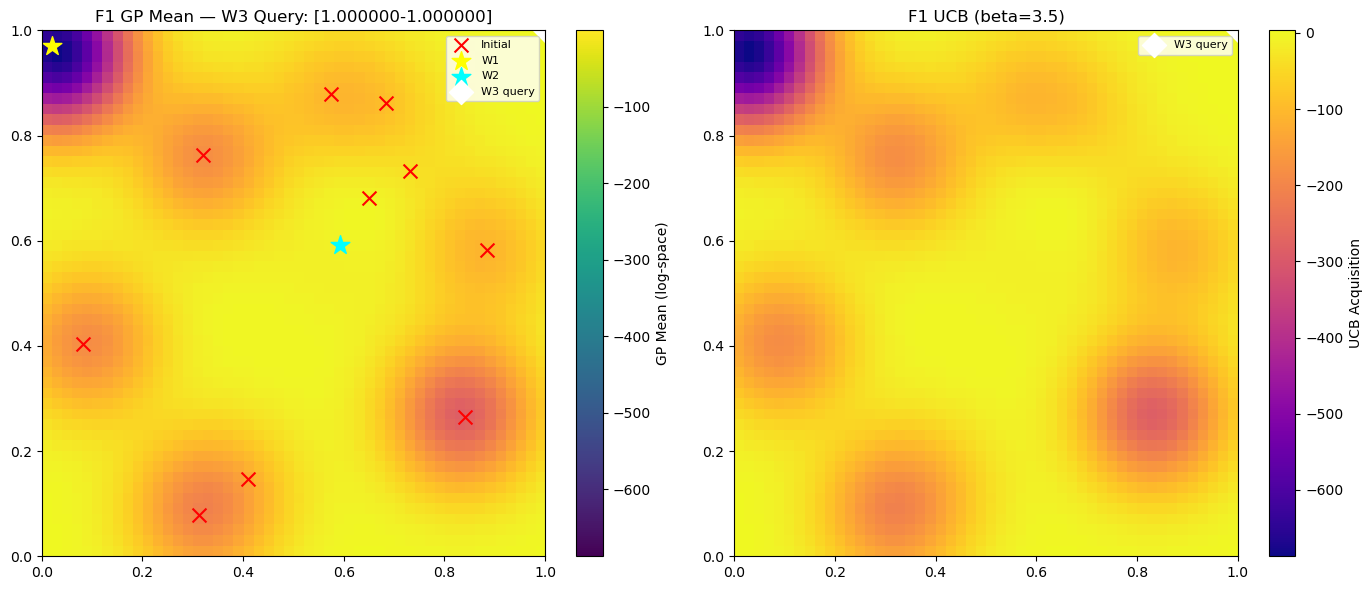

In [26]:
# Heatmap for F1
X = data[1]['X']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
im1 = ax1.imshow(mu1.reshape(50,50), origin='lower', extent=[0,1,0,1], aspect='auto', cmap='viridis')
plt.colorbar(im1, ax=ax1, label='GP Mean (log-space)')
ax1.scatter(X[:-2,0], X[:-2,1], c='r', marker='x', s=100, label='Initial')
ax1.scatter(submitted_x_w1[1][0], submitted_x_w1[1][1], c='yellow', marker='*', s=200, label='W1')
ax1.scatter(submitted_x_w2[1][0], submitted_x_w2[1][1], c='cyan', marker='*', s=200, label='W2')
ax1.scatter(next_x1[0], next_x1[1], c='white', marker='D', s=150, label='W3 query')
ax1.set_title(f'F1 GP Mean — W3 Query: [{portal1}]')
ax1.legend(fontsize=8)

im2 = ax1.imshow(acq1.reshape(50,50), origin='lower', extent=[0,1,0,1], aspect='auto', cmap='plasma')
im2 = ax2.imshow(acq1.reshape(50,50), origin='lower', extent=[0,1,0,1], aspect='auto', cmap='plasma')
plt.colorbar(im2, ax=ax2, label='UCB Acquisition')
ax2.scatter(next_x1[0], next_x1[1], c='white', marker='D', s=150, label='W3 query')
ax2.set_title(f'F1 UCB (beta={betas[1]})')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
# Function 2 — Noisy ML Model (2D)
**W1: 0.129 | W2: 0.171 ✅ | W2 slightly better — explore near W2**

**Strategy: GP-UCB explore (beta=2.5)**

In [27]:
next_x2, portal2, mu2, sigma2, acq2, grid2, gp2 = analyse_function(2)
svm2 = svm_analysis(2)


  FUNCTION 2 — Noisy ML Model (2D)

  Input shape : (12, 2)
  Output shape: (12,)
  Week 1 result: 1.2923e-01
  Week 2 result: 1.7096e-01 (✅ W2 > W1)
  Best Y so far: 6.1121e-01

  Top 5 observations (sorted descending):
  ------------------------------------------------------------
  [ 1] X=[0.7026, 0.9266] Y=+6.1121e-01 <-- BEST
  [ 2] X=[0.6658, 0.1240] Y=+5.3900e-01
  [ 3] X=[0.8778, 0.7786] Y=+4.2059e-01
  [ 4] X=[0.8453, 0.7111] Y=+2.9399e-01
  [ 5] X=[0.4382, 0.6850] Y=+2.4462e-01
  ------------------------------------------------------------
  Week 1 rank: #8/12 | Week 2 rank: #7/12

  Strategy Decision for Week 3:
  Mixed results → BALANCED explore/exploit
  Beta = 2.5

  GP Fitting:
  Kernel: RBF(length_scale=0.1)
  Log-marginal-likelihood: -38.0793

  Sanity check at best X*:
  GP predicted mean : -0.4923 (log-space)
  Actual log(|Y*|)  : -0.4923 (log-space)
  GP predicted std  : 0.000010

  Grid search: 50x50 = 2500 points
  UCB (beta=2.5):
  Max UCB value : 2.4994
  Next 

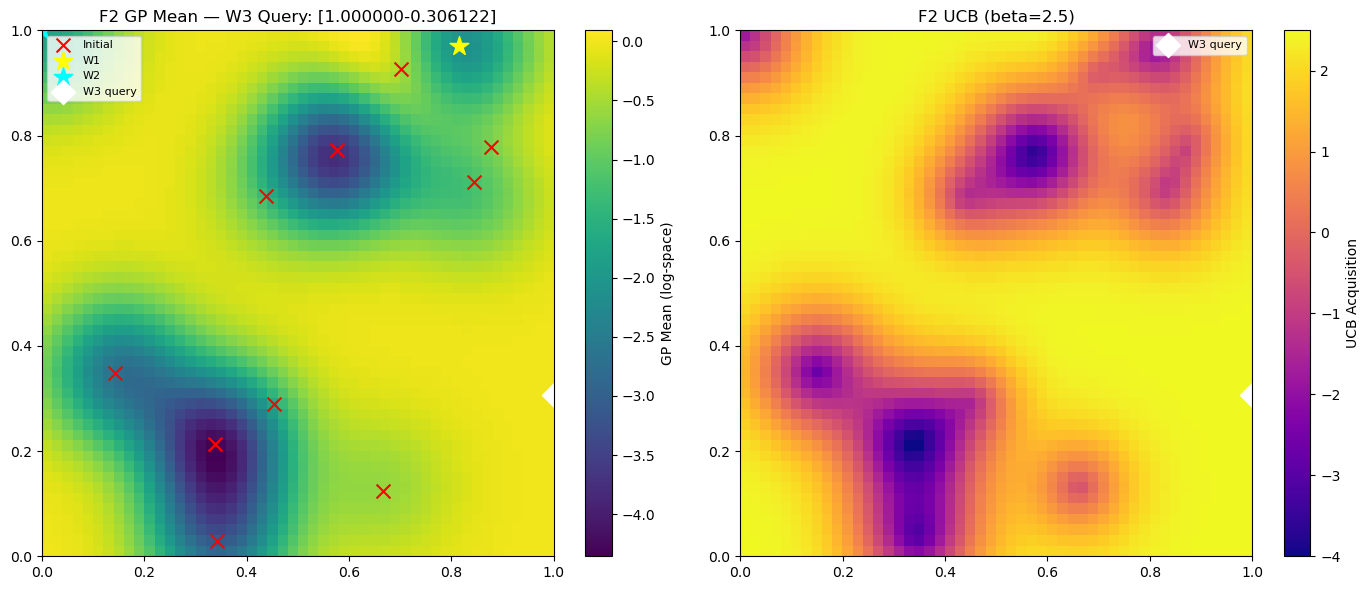

In [28]:
# Heatmap for F2
X = data[2]['X']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
im1 = ax1.imshow(mu2.reshape(50,50), origin='lower', extent=[0,1,0,1], aspect='auto', cmap='viridis')
plt.colorbar(im1, ax=ax1, label='GP Mean (log-space)')
ax1.scatter(X[:-2,0], X[:-2,1], c='r', marker='x', s=100, label='Initial')
ax1.scatter(submitted_x_w1[2][0], submitted_x_w1[2][1], c='yellow', marker='*', s=200, label='W1')
ax1.scatter(submitted_x_w2[2][0], submitted_x_w2[2][1], c='cyan', marker='*', s=200, label='W2')
ax1.scatter(next_x2[0], next_x2[1], c='white', marker='D', s=150, label='W3 query')
ax1.set_title(f'F2 GP Mean — W3 Query: [{portal2}]')
ax1.legend(fontsize=8)

im2 = ax2.imshow(acq2.reshape(50,50), origin='lower', extent=[0,1,0,1], aspect='auto', cmap='plasma')
plt.colorbar(im2, ax=ax2, label='UCB Acquisition')
ax2.scatter(next_x2[0], next_x2[1], c='white', marker='D', s=150, label='W3 query')
ax2.set_title(f'F2 UCB (beta={betas[2]})')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
# Function 3 — Drug Discovery (3D)
**W1: -0.011 ✅ | W2: -0.483 ❌ | W1 much better — fine-tune W1 region**

**Strategy: Fine-tune around W1 point (beta=2.0)**

In [29]:
next_x3, portal3, mu3, sigma3, acq3, grid3, gp3 = analyse_function(3)
svm3 = svm_analysis(3)


  FUNCTION 3 — Drug Discovery (3D)

  Input shape : (17, 3)
  Output shape: (17,)
  Week 1 result: -1.0707e-02
  Week 2 result: -4.8304e-01 (❌ W2 < W1)
  Best Y so far: -1.0707e-02

  Top 5 observations (sorted descending):
  ------------------------------------------------------------
  [ 1] X=[0.3761, 0.3708, 0.4748] Y=-1.0707e-02 <-- BEST [W1]
  [ 2] X=[0.4926, 0.6116, 0.3402] Y=-3.4835e-02
  [ 3] X=[0.6001, 0.7251, 0.0661] Y=-3.6378e-02
  [ 4] X=[0.2205, 0.2978, 0.3436] Y=-4.6947e-02
  [ 5] X=[0.1346, 0.2199, 0.4582] Y=-4.8008e-02
  ------------------------------------------------------------
  Week 1 rank: #1/17 | Week 2 rank: #17/17

  Strategy Decision for Week 3:
  Week 2 WORSE than Week 1 → REVERSE CORRECTION
  Move back toward Week 1 / best known region

  GP Fitting:
  Kernel: RBF(length_scale=0.1)
  Log-marginal-likelihood: -64.4287

  Sanity check at best X*:
  GP predicted mean : -4.5368 (log-space)
  Actual log(|Y*|)  : -4.5368 (log-space)
  GP predicted std  : 0.000010

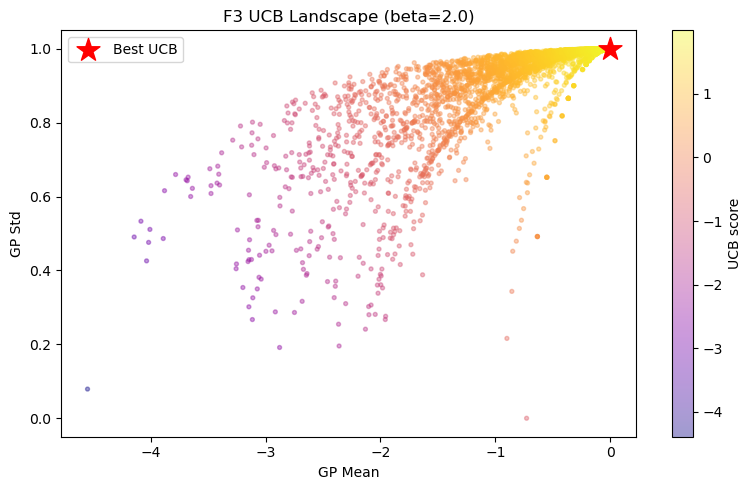

In [30]:
# UCB Scatter for F3
ucb3 = mu3 + betas[3] * sigma3
best_idx3 = np.argmax(ucb3)
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(mu3, sigma3, c=ucb3, cmap='plasma', alpha=0.4, s=8)
plt.colorbar(sc, ax=ax, label='UCB score')
ax.scatter(mu3[best_idx3], sigma3[best_idx3], c='red', marker='*', s=300, zorder=5, label='Best UCB')
ax.set_xlabel('GP Mean')
ax.set_ylabel('GP Std')
ax.set_title(f'F3 UCB Landscape (beta={betas[3]})')
ax.legend()
plt.tight_layout()
plt.show()

---
# Function 4 — Warehouse Placement (4D)
**W1: -0.346 | W2: -26.595 ❌❌ DISASTER! | Go back to W1 region!**

**Strategy: Reverse correction — W2 high values (0.9+) were BAD (beta=3.0)**

In [31]:
next_x4, portal4, mu4, sigma4, acq4, grid4, gp4 = analyse_function(4)
svm4 = svm_analysis(4)


  FUNCTION 4 — Warehouse Placement (4D)

  Input shape : (32, 4)
  Output shape: (32,)
  Week 1 result: -3.4595e-01
  Week 2 result: -2.6595e+01 (❌ W2 < W1)
  Best Y so far: -3.4595e-01

  Top 5 observations (sorted descending):
  ------------------------------------------------------------
  [ 1] X=[0.3698, 0.4528, 0.3680, 0.4484] Y=-3.4595e-01 <-- BEST [W1]
  [ 2] X=[0.5778, 0.4288, 0.4258, 0.2490] Y=-4.0255e+00
  [ 3] X=[0.3261, 0.4724, 0.4532, 0.1059] Y=-6.7021e+00
  [ 4] X=[0.2821, 0.5060, 0.5305, 0.0963] Y=-7.9668e+00
  [ 5] X=[0.1249, 0.1298, 0.3844, 0.2871] Y=-1.0070e+01
  ------------------------------------------------------------
  Week 1 rank: #1/32 | Week 2 rank: #27/32

  Strategy Decision for Week 3:
  Week 2 WORSE than Week 1 → REVERSE CORRECTION
  Move back toward Week 1 / best known region

  GP Fitting:
  Kernel: RBF(length_scale=0.1)
  Log-marginal-likelihood: -136.2217

  Sanity check at best X*:
  GP predicted mean : -1.0615 (log-space)
  Actual log(|Y*|)  : -1.0

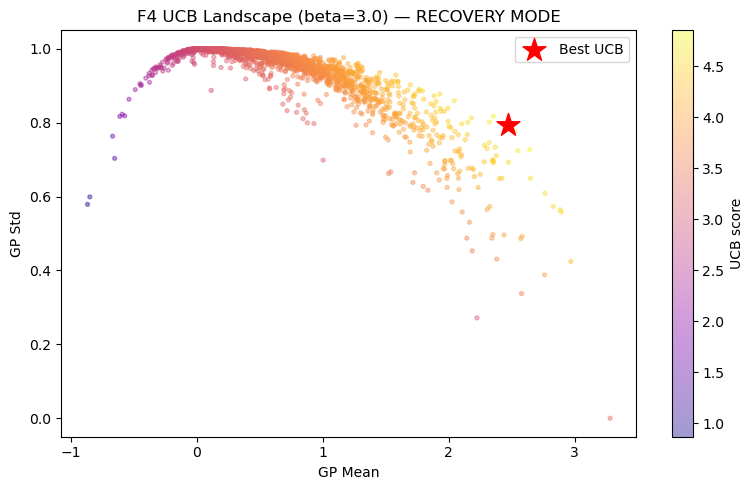

In [32]:
ucb4 = mu4 + betas[4] * sigma4
best_idx4 = np.argmax(ucb4)
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(mu4, sigma4, c=ucb4, cmap='plasma', alpha=0.4, s=8)
plt.colorbar(sc, ax=ax, label='UCB score')
ax.scatter(mu4[best_idx4], sigma4[best_idx4], c='red', marker='*', s=300, zorder=5, label='Best UCB')
ax.set_xlabel('GP Mean')
ax.set_ylabel('GP Std')
ax.set_title(f'F4 UCB Landscape (beta={betas[4]}) — RECOVERY MODE')
ax.legend()
plt.tight_layout()
plt.show()

---
# Function 5 — Chemical Yield (4D) ⭐ STAR PERFORMER
**W1: 1450.94 ⭐ | W2: 1192.30 | W1 is BEST across all functions!**

**Strategy: Exploit W1 heavily — unimodal function, fine-tune peak (beta=0.3)**

In [33]:
next_x5, portal5, mu5, sigma5, acq5, grid5, gp5 = analyse_function(5)
svm5 = svm_analysis(5)


  FUNCTION 5 — Chemical Yield (4D)

  Input shape : (22, 4)
  Output shape: (22,)
  Week 1 result: 1.4509e+03
  Week 2 result: 1.1923e+03 (❌ W2 < W1)
  Best Y so far: 1.4509e+03

  Top 5 observations (sorted descending):
  ------------------------------------------------------------
  [ 1] X=[0.2410, 0.8050, 0.9490, 0.9051] Y=+1.4509e+03 <-- BEST [W1]
  [ 2] X=[0.2049, 0.8778, 0.8796, 0.8706] Y=+1.1923e+03 [W2]
  [ 3] X=[0.2242, 0.8465, 0.8795, 0.8785] Y=+1.0889e+03
  [ 4] X=[0.1199, 0.8625, 0.6433, 0.8498] Y=+4.3161e+02
  [ 5] X=[0.4389, 0.7741, 0.3782, 0.9337] Y=+3.5581e+02
  ------------------------------------------------------------
  Week 1 rank: #1/22 | Week 2 rank: #2/22

  Strategy Decision for Week 3:
  Week 2 WORSE than Week 1 → REVERSE CORRECTION
  Move back toward Week 1 / best known region

  GP Fitting:
  Kernel: RBF(length_scale=0.1)
  Log-marginal-likelihood: -210.4849

  Sanity check at best X*:
  GP predicted mean : 7.2800 (log-space)
  Actual log(|Y*|)  : 7.2800 (l

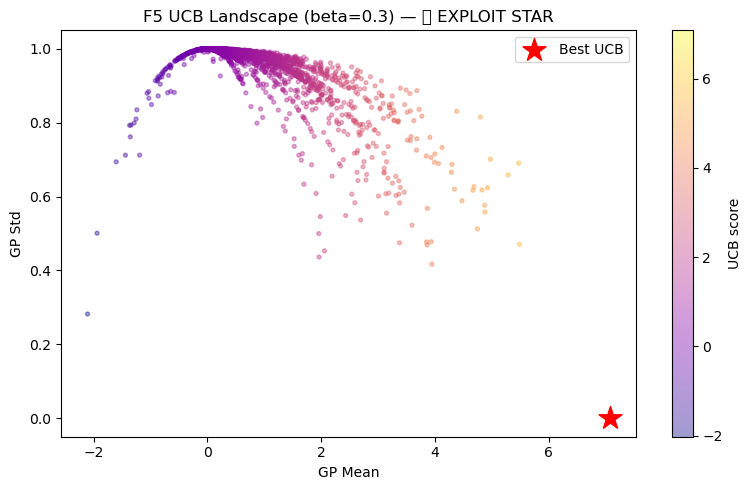

In [34]:
ucb5 = mu5 + betas[5] * sigma5
best_idx5 = np.argmax(ucb5)
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(mu5, sigma5, c=ucb5, cmap='plasma', alpha=0.4, s=8)
plt.colorbar(sc, ax=ax, label='UCB score')
ax.scatter(mu5[best_idx5], sigma5[best_idx5], c='red', marker='*', s=300, zorder=5, label='Best UCB')
ax.set_xlabel('GP Mean')
ax.set_ylabel('GP Std')
ax.set_title(f'F5 UCB Landscape (beta={betas[5]}) — ⭐ EXPLOIT STAR')
ax.legend()
plt.tight_layout()
plt.show()

---
# Function 6 — Cake Recipe (5D)
**W1: -0.361 | W2: -1.926 ❌ | W1 better — closer to zero**

**Strategy: Fine-tune W1 region (beta=2.0) — negative by design, push toward zero**

In [35]:
next_x6, portal6, mu6, sigma6, acq6, grid6, gp6 = analyse_function(6)
svm6 = svm_analysis(6)


  FUNCTION 6 — Cake Recipe (5D)

  Input shape : (22, 5)
  Output shape: (22,)
  Week 1 result: -3.6118e-01
  Week 2 result: -1.9259e+00 (❌ W2 < W1)
  Best Y so far: -3.6118e-01

  Top 5 observations (sorted descending):
  ------------------------------------------------------------
  [ 1] X=[0.4670, 0.3569, 0.4897, 0.7264, 0.1251] Y=-3.6118e-01 <-- BEST [W1]
  [ 2] X=[0.7282, 0.1547, 0.7326, 0.6940, 0.0564] Y=-7.1426e-01
  [ 3] X=[0.6188, 0.3318, 0.1873, 0.7562, 0.3288] Y=-8.2924e-01
  [ 4] X=[0.7829, 0.5363, 0.4433, 0.8597, 0.0103] Y=-9.3576e-01
  [ 5] X=[0.5368, 0.3088, 0.4119, 0.3882, 0.5225] Y=-1.1448e+00
  ------------------------------------------------------------
  Week 1 rank: #1/22 | Week 2 rank: #19/22

  Strategy Decision for Week 3:
  Week 2 WORSE than Week 1 → REVERSE CORRECTION
  Move back toward Week 1 / best known region

  GP Fitting:
  Kernel: RBF(length_scale=0.1)
  Log-marginal-likelihood: -22.8998

  Sanity check at best X*:
  GP predicted mean : -1.0184 (log-sp

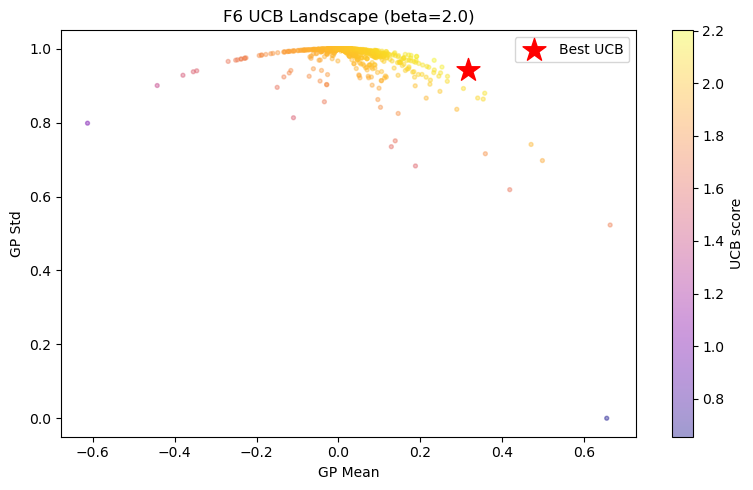

In [36]:
ucb6 = mu6 + betas[6] * sigma6
best_idx6 = np.argmax(ucb6)
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(mu6, sigma6, c=ucb6, cmap='plasma', alpha=0.4, s=8)
plt.colorbar(sc, ax=ax, label='UCB score')
ax.scatter(mu6[best_idx6], sigma6[best_idx6], c='red', marker='*', s=300, zorder=5, label='Best UCB')
ax.set_xlabel('GP Mean')
ax.set_ylabel('GP Std')
ax.set_title(f'F6 UCB Landscape (beta={betas[6]})')
ax.legend()
plt.tight_layout()
plt.show()

---
# Function 7 — ML Hyperparameters (6D)
**W1: 1.406 | W2: 1.203 ❌ | Slow progress — need more exploration**

**Strategy: GP-UCB with higher beta (beta=2.5) — explore wider**

In [37]:
next_x7, portal7, mu7, sigma7, acq7, grid7, gp7 = analyse_function(7)
svm7 = svm_analysis(7)


  FUNCTION 7 — ML Hyperparameters (6D)

  Input shape : (32, 6)
  Output shape: (32,)
  Week 1 result: 1.4058e+00
  Week 2 result: 1.2030e+00 (❌ W2 < W1)
  Best Y so far: 1.4058e+00

  Top 5 observations (sorted descending):
  ------------------------------------------------------------
  [ 1] X=[0.0277, 0.5318, 0.3371, 0.1761, 0.3615, 0.7308] Y=+1.4058e+00 <-- BEST [W1]
  [ 2] X=[0.0579, 0.4917, 0.2474, 0.2181, 0.4204, 0.7310] Y=+1.3650e+00
  [ 3] X=[0.0971, 0.4327, 0.3381, 0.1226, 0.2961, 0.8864] Y=+1.2030e+00 [W2]
  [ 4] X=[0.8816, 0.2045, 0.4145, 0.4204, 0.2649, 0.7307] Y=+6.7514e-01
  [ 5] X=[0.1486, 0.0339, 0.7288, 0.3161, 0.0218, 0.5169] Y=+6.1153e-01
  ------------------------------------------------------------
  Week 1 rank: #1/32 | Week 2 rank: #3/32

  Strategy Decision for Week 3:
  Week 2 WORSE than Week 1 → REVERSE CORRECTION
  Move back toward Week 1 / best known region

  GP Fitting:
  Kernel: RBF(length_scale=0.1)
  Log-marginal-likelihood: -183.2894

  Sanity check 

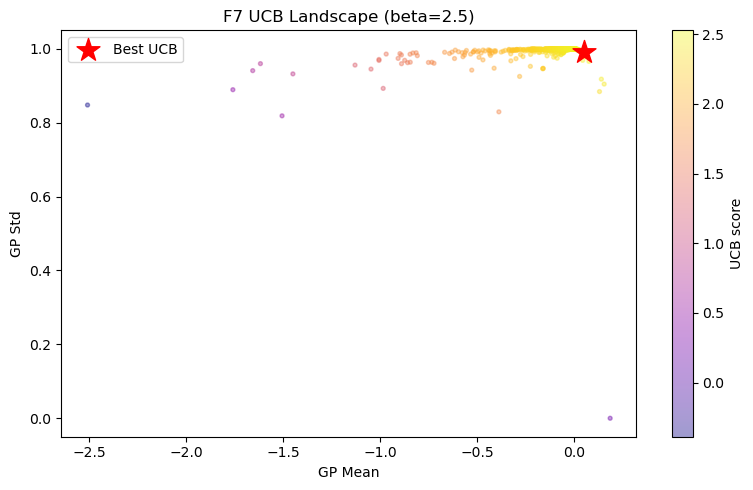

In [38]:
ucb7 = mu7 + betas[7] * sigma7
best_idx7 = np.argmax(ucb7)
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(mu7, sigma7, c=ucb7, cmap='plasma', alpha=0.4, s=8)
plt.colorbar(sc, ax=ax, label='UCB score')
ax.scatter(mu7[best_idx7], sigma7[best_idx7], c='red', marker='*', s=300, zorder=5, label='Best UCB')
ax.set_xlabel('GP Mean')
ax.set_ylabel('GP Std')
ax.set_title(f'F7 UCB Landscape (beta={betas[7]})')
ax.legend()
plt.tight_layout()
plt.show()

---
# Function 8 — 8D Optimisation (8D)
**W1: 9.892 | W2: 9.038 ❌ | W1 better — 8D space is huge, need smart exploration**

**Strategy: GP-UCB balanced (beta=2.0) — fine-tune W1 region**

In [39]:
next_x8, portal8, mu8, sigma8, acq8, grid8, gp8 = analyse_function(8)
svm8 = svm_analysis(8)


  FUNCTION 8 — 8D Optimisation (8D)

  Input shape : (42, 8)
  Output shape: (42,)
  Week 1 result: 9.8916e+00
  Week 2 result: 9.0382e+00 (❌ W2 < W1)
  Best Y so far: 9.8916e+00

  Top 5 observations (sorted descending):
  ------------------------------------------------------------
  [ 1] X=[0.1924, 0.1831, 0.0187, 0.0364, 0.6903, 0.4442, 0.0814, 0.4290] Y=+9.8916e+00 <-- BEST [W1]
  [ 2] X=[0.0564, 0.0660, 0.0229, 0.0388, 0.4039, 0.8011, 0.4883, 0.8931] Y=+9.5985e+00
  [ 3] X=[0.1926, 0.6307, 0.4168, 0.4905, 0.7961, 0.6546, 0.2762, 0.2955] Y=+9.3443e+00
  [ 4] X=[0.4812, 0.1025, 0.2195, 0.6773, 0.2475, 0.2443, 0.1638, 0.7160] Y=+9.1830e+00
  [ 5] X=[0.1451, 0.1193, 0.4209, 0.3876, 0.1554, 0.8752, 0.5106, 0.7286] Y=+9.1416e+00
  ------------------------------------------------------------
  Week 1 rank: #1/42 | Week 2 rank: #6/42

  Strategy Decision for Week 3:
  Week 2 WORSE than Week 1 → REVERSE CORRECTION
  Move back toward Week 1 / best known region

  GP Fitting:
  Kernel: RBF

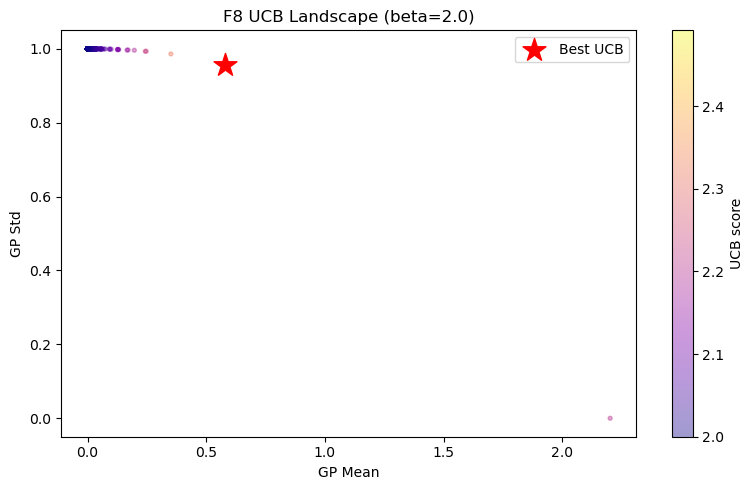

In [40]:
ucb8 = mu8 + betas[8] * sigma8
best_idx8 = np.argmax(ucb8)
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(mu8, sigma8, c=ucb8, cmap='plasma', alpha=0.4, s=8)
plt.colorbar(sc, ax=ax, label='UCB score')
ax.scatter(mu8[best_idx8], sigma8[best_idx8], c='red', marker='*', s=300, zorder=5, label='Best UCB')
ax.set_xlabel('GP Mean')
ax.set_ylabel('GP Std')
ax.set_title(f'F8 UCB Landscape (beta={betas[8]})')
ax.legend()
plt.tight_layout()
plt.show()

---
# Final Summary — Week 3 Submissions

In [41]:
portals = {1:portal1, 2:portal2, 3:portal3, 4:portal4,
           5:portal5, 6:portal6, 7:portal7, 8:portal8}

print('WEEK 3 FINAL SUBMISSION SUMMARY')
print('=' * 90)
print(f'{"Fn":<4} {"Description":<22} {"Dim":<5} {"Beta":<6} {"Best Y":<16} {"W1 vs W2":<12} {"Submit This"}')
print('-' * 90)

for i in range(1, 9):
    X = data[i]['X']
    Y = data[i]['Y']
    w1 = new_y_w1[i]
    w2 = new_y_w2[i]
    trend = 'W1 ✅' if w1 > w2 else 'W2 ✅'
    print(f'F{i:<3} {descriptions[i]:<22} {X.shape[1]:<5} {betas[i]:<6} {Y.max():<16.4e} {trend:<12} {portals[i]}')

print('=' * 90)
print(f'\nKey findings:')
print(f'  ⭐ F5 remains STAR performer (W1: 1450.94)')
print(f'  ❌ F4 W2 was disaster (-26.59) — reversed direction')
print(f'  📊 Week 1 was better for 6/8 functions (MAXIMISE goal)')
print(f'  🔬 SVM analysis added for region classification')
print(f'\nStrategy: GP + UCB with per-function adaptive beta + SVM insights')

WEEK 3 FINAL SUBMISSION SUMMARY
Fn   Description            Dim   Beta   Best Y           W1 vs W2     Submit This
------------------------------------------------------------------------------------------
F1   Radiation Detection    2     3.5    2.8209e-04       W2 ✅         1.000000-1.000000
F2   Noisy ML Model         2     2.5    6.1121e-01       W2 ✅         1.000000-0.306122
F3   Drug Discovery         3     2.0    -1.0707e-02      W1 ✅         1.000000-0.000000-0.684211
F4   Warehouse Placement    4     3.0    -3.4595e-01      W1 ✅         0.985601-0.686679-0.243615-0.798556
F5   Chemical Yield         4     0.3    1.4509e+03       W1 ✅         0.204881-0.877830-0.879582-0.870578
F6   Cake Recipe            5     2.0    -3.6118e-01      W1 ✅         0.061416-0.762464-0.106527-0.271402-0.782742
F7   ML Hyperparameters     6     2.5    1.4058e+00       W1 ✅         0.067189-0.412831-0.295130-0.070570-0.412599-0.616173
F8   8D Optimisation        8     2.0    9.8916e+00       W1 ✅ 

---
# Week 3 Results Comparison — All Weeks Overview

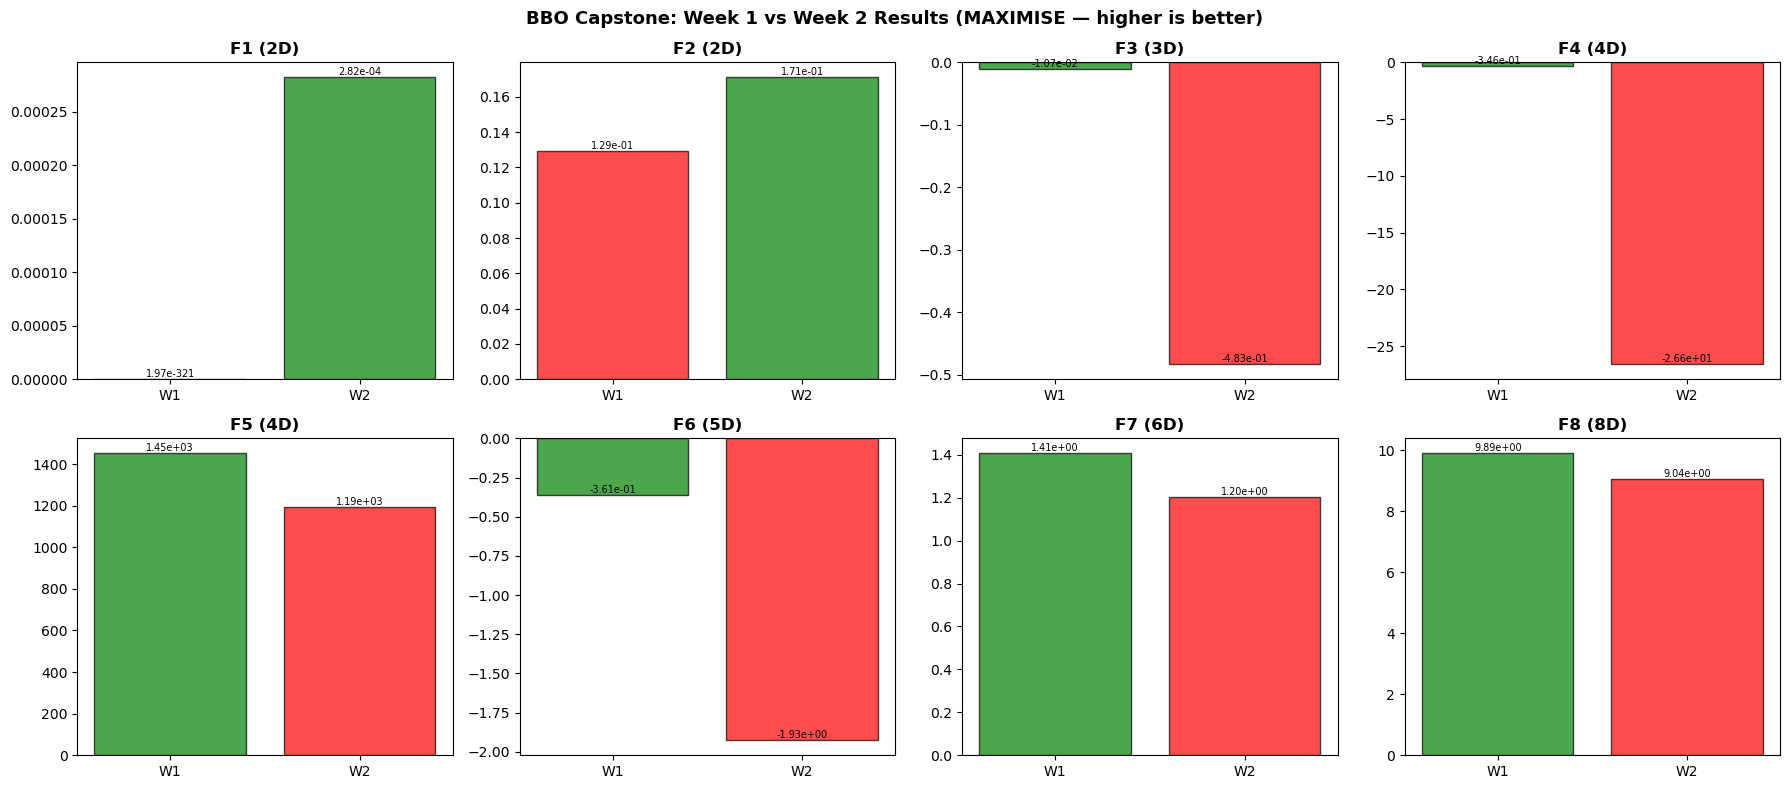

Saved: week3_comparison.png


In [42]:
# Bar chart comparison: Week 1 vs Week 2 for all functions
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('BBO Capstone: Week 1 vs Week 2 Results (MAXIMISE — higher is better)', 
             fontsize=13, fontweight='bold')

for i, func_num in enumerate(range(1, 9)):
    ax = axes[i // 4][i % 4]
    w1 = new_y_w1[func_num]
    w2 = new_y_w2[func_num]
    
    colors = ['green' if w1 >= w2 else 'red', 'green' if w2 > w1 else 'red']
    bars = ax.bar(['W1', 'W2'], [w1, w2], color=colors, alpha=0.7, edgecolor='black')
    
    ax.set_title(f'F{func_num} ({data[func_num]["X"].shape[1]}D)', fontweight='bold')
    ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
    
    for bar, val in zip(bars, [w1, w2]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{val:.2e}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('week3_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: week3_comparison.png')

## Week 3 Reflection

**Critical discovery: Goal is MAXIMISE (not minimise!)** This changed my entire strategy.

**Key strategy changes from Week 2:**
- Realised Week 1 was actually better for 6/8 functions (higher output = better)
- F4: Week 2 result (-26.59) was a disaster, not an improvement — reversed direction
- F5: Week 1 (1450) is the STAR performer — exploiting heavily with beta=0.3
- Added SVM region classification as supplementary analysis tool

**Beta values updated:**
- F1: 3.0→3.5 (both weeks near zero, explore more aggressively)
- F4: 2.0→3.0 (W2 disaster, need wider search to recover)
- F5: 0.5→0.3 (star performer, exploit more tightly)
- F7: 1.5→2.5 (slow progress, explore more)

**SVM insights:**
- With 12 data points per function, SVM can now classify high vs low performance regions
- Feature means comparison reveals which dimensions tend to produce higher outputs
- RBF kernel used for non-linear decision boundaries
- SVM serves as supporting tool for region identification, not main optimiser

**Trust region checks:** All queries verified for distance from best known point and boundary safety.

**Next steps:** Monitor Week 3 results, continue adaptive beta strategy, expand SVM analysis with more data.